In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
#@title pre-computed COHA values

len_weights_a = [(1,
  np.float64(5.072608768244299),
  np.array([4.9199152 , 4.9199152 , 4.9199152 , 5.34461809, 5.34566193])),
 (2,
  np.float64(3.3822968890674834),
  np.array([3.14453279, 3.32054067, 3.42265987, 3.47407448, 3.55508876])),
 (3,
  np.float64(2.5552707778459793),
  np.array([2.36386538, 2.51312685, 2.51509032, 2.64514112, 2.72023058])),
 (4,
  np.float64(2.0965680724942617),
  np.array([1.92431951, 2.00931681, 2.08084661, 2.16851592, 2.29383588])),
 (5,
  np.float64(1.787157510291713),
  np.array([1.56837456, 1.69971189, 1.7596103 , 1.85598421, 2.0075414 ])),
 (6,
  np.float64(1.5826397043533142),
  np.array([1.39892614, 1.49441409, 1.55927694, 1.6474738 , 1.82261169])),
 (7,
  np.float64(1.4100846195458345),
  np.array([1.23074555, 1.31693244, 1.40038896, 1.46751809, 1.64786448])),
 (8,
  np.float64(1.2818991806718023),
  np.array([1.10219896, 1.19128025, 1.25538738, 1.34645713, 1.52446985])),
 (9,
  np.float64(1.1667674467249871),
  np.array([1.01197457, 1.08008969, 1.14189661, 1.22116923, 1.40067452])),
 (10,
  np.float64(1.0729214040593975),
  np.array([0.89605266, 0.9841188 , 1.04875624, 1.13328791, 1.31394577])),
 (11,
  np.float64(1.0125222356817662),
  np.array([0.8513276 , 0.92454852, 0.9892897 , 1.06300437, 1.24440588])),
 (12,
  np.float64(0.9461147486301424),
  np.array([0.79310137, 0.85668564, 0.91234386, 0.98985165, 1.18837744])),
 (13,
  np.float64(0.9037632772617041),
  np.array([0.7416997 , 0.8171512 , 0.86220562, 0.94782039, 1.18645897])),
 (14,
  np.float64(0.8664013681019616),
  np.array([0.69491547, 0.75753318, 0.81164628, 0.9150905 , 1.19476838])),
 (15,
  np.float64(0.892959436212798),
  np.array([0.72243517, 0.77841496, 0.86606076, 0.92179012, 1.23893867])),
 (16,
  np.float64(0.9064988453783559),
  np.array([0.61948484, 0.77084906, 0.8363501 , 0.96851359, 1.36396447]))
 ]

In [5]:
#@title model fitting for baseline

import numpy as np
from scipy.optimize import curve_fit

how_many = len(len_weights_a)

# Extract values
lengths = [x[0] for x in len_weights_a]
means   = [x[1] for x in len_weights_a]
medians = [x[2][2] for x in len_weights_a]
p5  = [x[2][0] for x in len_weights_a]
p25 = [x[2][1] for x in len_weights_a]
p75 = [x[2][3] for x in len_weights_a]
p95 = [x[2][4] for x in len_weights_a]


n = np.array([d for d in lengths], dtype=float)
y = np.array([d for d in means], dtype=float)

def fit_model(n,a,b,c):
    return a + b/(n**c)

p0=[0.1,1,0.5]
popt, pcov = curve_fit(fit_model,n,y, p0, maxfev=20000)

popt


array([-0.21229168,  5.32128903,  0.60232571])

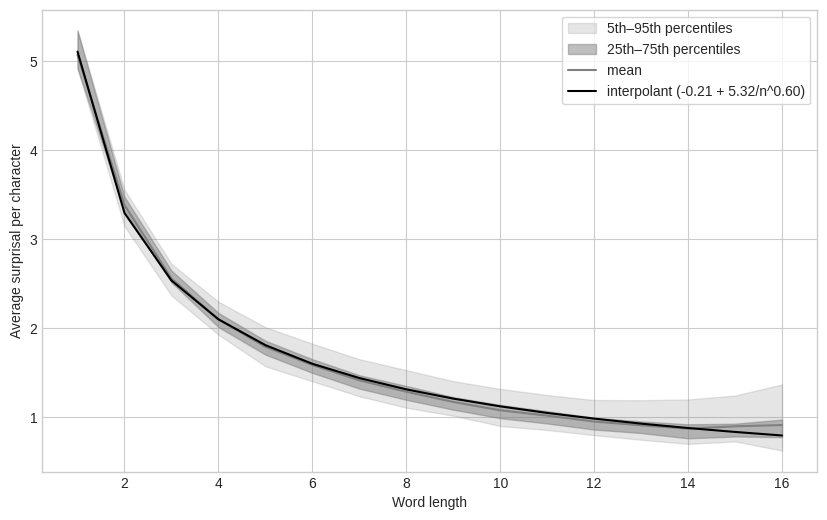

In [7]:
#@title plot baseline

plt.figure(figsize=(10,6))
plt.style.use('seaborn-v0_8-whitegrid')
plt.gray()

# shaded area for IQR
plt.fill_between(lengths, p5, p95, alpha=0.2, color='gray', label="5th–95th percentiles")
plt.fill_between(lengths, p25, p75, alpha=0.5, color = 'gray', label="25th–75th percentiles")
plt.plot(lengths, means, color='gray',label="mean")

a, b, c = popt

interp = [a + b/t**c for t in range(1,how_many+1)]
plt.plot(range(1,how_many+1), interp, label = f'interpolant ({a:.2f} + {b:.2f}/n^{c:.2f})', color='black')


plt.xlabel("Word length")
plt.ylabel("Average surprisal per character")
plt.legend(frameon=True)
plt.show()

In [10]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

save_path = "/content/drive/MyDrive/Distant Reading Word Embedding/PEIRCE CODE/char_lstm_COHA_1810-1910_v2.pt" # Distant Reading Word Embedding/PEIRCE CODE/


Mounted at /content/drive


In [11]:
#@title load LSTM model

#<begin> and <end> tokens

BOS = "🅱"
EOS = "⏹"

import torch.nn as nn

class CharLSTM(nn.Module):
    def __init__(self, vocab_size=53, emb=30, hid=512, layers=1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb)
        self.lstm = nn.LSTM(emb, hid, num_layers=layers, batch_first=True)
        self.fc = nn.Linear(hid, vocab_size)

    def forward(self, x, h=None):
        x = self.emb(x)
        out, h = self.lstm(x, h)
        logits = self.fc(out)
        return logits, h


# save_path = 'char_lstm_COHA_1810-1910_v2.pt'
ckpt = torch.load(save_path, map_location="cpu")

stoi = ckpt["stoi"]
itos = ckpt["itos"]
chars = ckpt["chars"]
vocab_size = ckpt["vocab_size"] # 53
block_size = ckpt["block_size"]

model = CharLSTM(vocab_size)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()


CharLSTM(
  (emb): Embedding(53, 30)
  (lstm): LSTM(30, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=53, bias=True)
)

In [14]:
#@title surprisal function

import math

def average_weight(n):
  a, b, c = popt
  interp = a + b/n**c
  return interp

def word_surprisal(word):
    text = BOS + word + EOS
    ids = [stoi[c] for c in text if c in stoi]

    total_surprisal = 0.0
    per_char = []

    h = None

    # iterate through characters except the last one
    for i in range(0,len(ids)-1):
        x = torch.tensor([[ids[i]]])
        logits, h = model(x, h)
        probs = torch.softmax(logits[0, -1], dim=0)

        nxt = ids[i+1]
        p = float(probs[nxt].detach())
        surprisal = -math.log(p + 1e-12)

        per_char.append((itos[nxt], surprisal, p))
        total_surprisal += surprisal

    avg = total_surprisal/((len(word)+1)*average_weight(len(word)))

    return total_surprisal, avg, per_char


word_surprisal('pragmaticism')

(17.47745160249083,
 np.float64(1.3733342319201265),
 [('p', 2.6526721575482313, 0.0704626739025116),
  ('r', 1.3139400553597715, 0.2687590420246124),
  ('a', 2.5318121859216642, 0.07951479405164719),
  ('g', 3.3104312959160294, 0.03650042787194252),
  ('m', 1.0623262849027983, 0.3456507921218872),
  ('a', 0.0613830282603286, 0.9404629468917847),
  ('t', 0.17372131222652104, 0.8405311107635498),
  ('i', 0.09281346845970821, 0.9113634824752808),
  ('c', 1.0645767666434303, 0.3448737859725952),
  ('i', 4.064789230886185, 0.017166607081890106),
  ('s', 1.053180108770547, 0.34882667660713196),
  ('m', 0.060898810965426146, 0.9409184455871582),
  ('⏹', 0.03490689663018925, 0.965695321559906)])